In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")

In [91]:
sms = pd.read_csv("../data/raw/spam.csv", encoding="latin-1")
sms.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [92]:
sms.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [93]:
sms.shape

(5572, 5)

In [94]:
sms.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True)

In [95]:
sms.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [96]:
sms.duplicated().sum()

np.int64(403)

In [97]:
sms.drop_duplicates(inplace=True)

In [98]:
sms.duplicated().sum()

np.int64(0)

In [99]:
sms.shape

(5169, 2)

In [100]:
sms = sms.rename(columns={"v1" : "target", "v2": "text"})

In [101]:
sms.sample()

,target,text
637,ham,When Ì_ login dat time... Dad fetching Ì_ home...


In [102]:
from sklearn.preprocessing import LabelEncoder

In [103]:
le = LabelEncoder()

In [104]:
sms['target'] = le.fit_transform(sms['target'])

In [105]:
sms.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


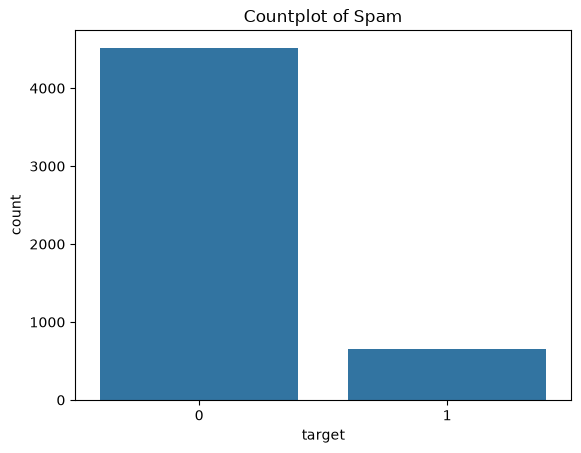

In [106]:
sns.countplot(x = 'target', data= sms)
plt.title("Countplot of Spam")
plt.show()

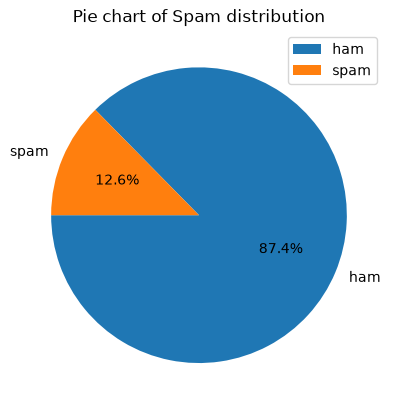

In [107]:
sms_count = sms['target'].value_counts()
plt.pie(sms_count, labels=["ham", "spam"], autopct='%1.1f%%', data=sms, startangle=180)
plt.title("Pie chart of Spam distribution")
plt.legend()
plt.show()

In [108]:
import nltk

In [109]:
nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\paude\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [110]:
sms['num_characters'] = sms['text'].apply(len)

In [111]:
sms.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [112]:
sms['num_sentence'] = sms['text'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [113]:
sms['num_words'] = sms['text'].apply(lambda x : len(nltk.word_tokenize(x)))

In [114]:
sms.head()

,target,text,num_characters,num_sentence,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,2,24
1,0,Ok lar... Joking wif u oni...,29,2,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,2,37
3,0,U dun say so early hor... U c already then say...,49,1,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,1,15


In [115]:
sms[['num_sentence', 'num_characters', 'num_words']].describe()

,num_sentence,num_characters,num_words
count,5169.000000,5169.000000,5169.000000
mean,1.965564,78.977945,18.455794
std,1.448541,58.236293,13.324758
min,1.000000,2.000000,1.000000
25%,1.000000,36.000000,9.000000
50%,1.000000,60.000000,15.000000
75%,2.000000,117.000000,26.000000
max,38.000000,910.000000,220.000000


In [116]:
#ham 

sms[sms['target']== 0][['num_sentence', 'num_characters', 'num_words']].describe()

,num_sentence,num_characters,num_words
count,4516.000000,4516.000000,4516.000000
mean,1.820195,70.459256,17.123782
std,1.383657,56.358207,13.493970
min,1.000000,2.000000,1.000000
25%,1.000000,34.000000,8.000000
50%,1.000000,52.000000,13.000000
75%,2.000000,90.000000,22.000000
max,38.000000,910.000000,220.000000


In [117]:
#spam 

sms[sms['target']== 1][['num_sentence', 'num_characters', 'num_words']].describe()

,num_sentence,num_characters,num_words
count,653.000000,653.000000,653.000000
mean,2.970904,137.891271,27.667688
std,1.488425,30.137753,7.008418
min,1.000000,13.000000,2.000000
25%,2.000000,132.000000,25.000000
50%,3.000000,149.000000,29.000000
75%,4.000000,157.000000,32.000000
max,9.000000,224.000000,46.000000


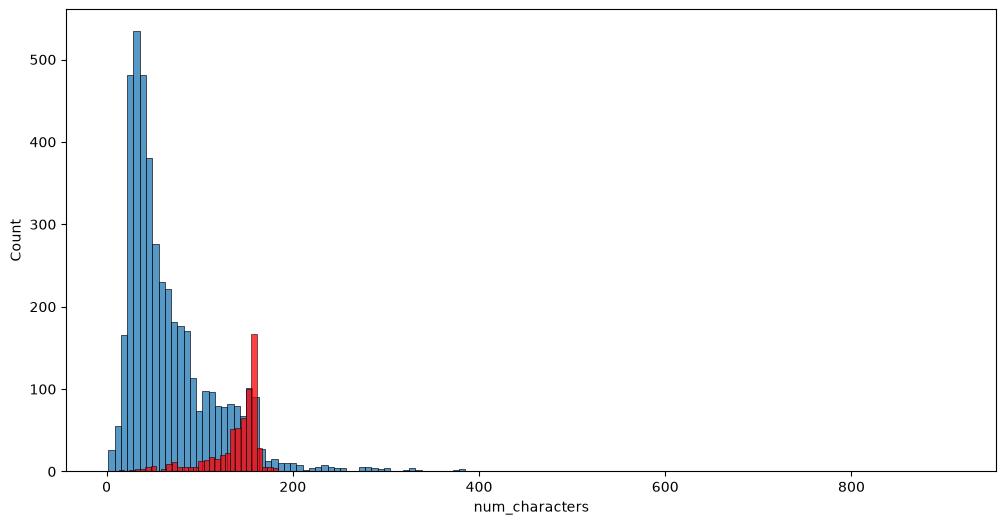

In [118]:
plt.figure(figsize=(12,6))
sns.histplot(sms[sms['target'] == 0]['num_characters'])
sns.histplot(sms[sms['target'] == 1]['num_characters'], color='red')
plt.show()

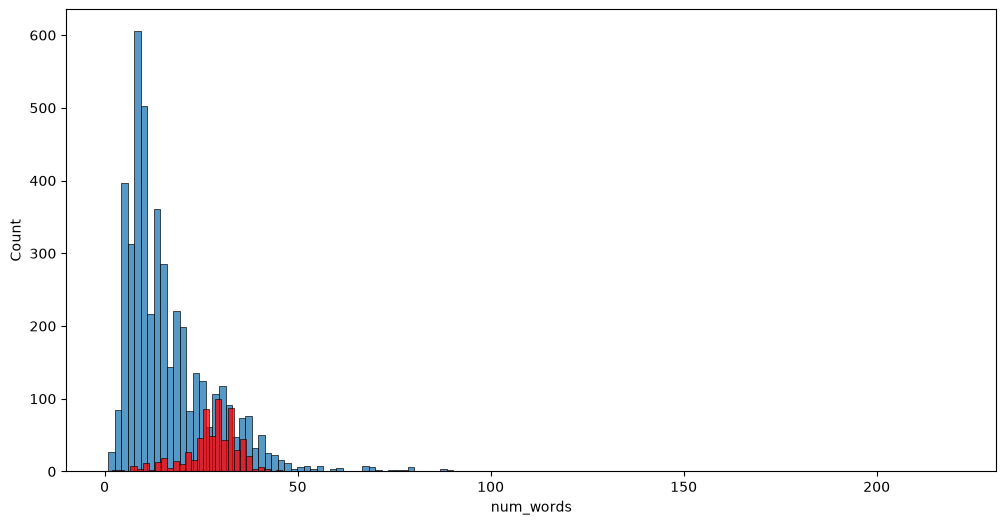

In [119]:
plt.figure(figsize=(12,6))
sns.histplot(sms[sms['target'] == 0]['num_words'])
sns.histplot(sms[sms['target'] == 1]['num_words'], color='red')
plt.show()

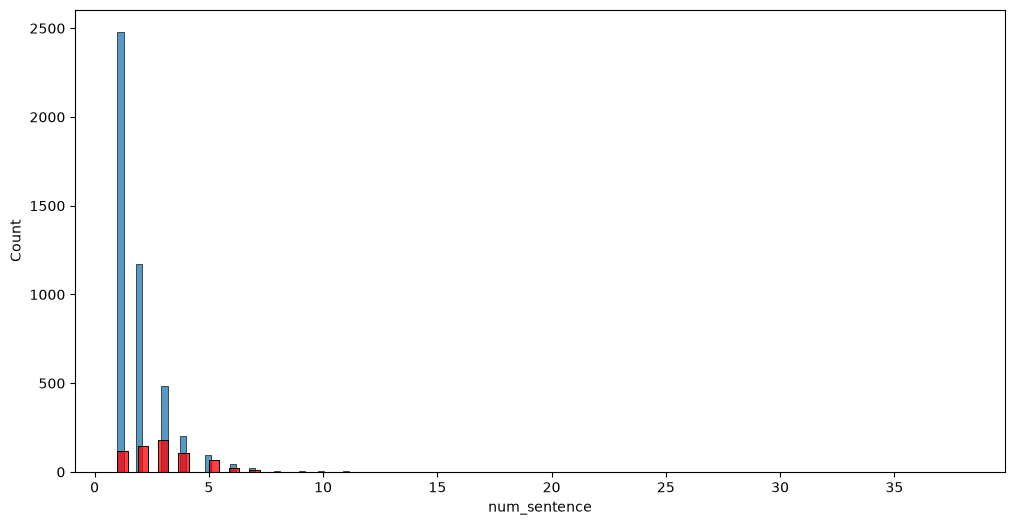

In [120]:
plt.figure(figsize=(12,6))
sns.histplot(sms[sms['target'] == 0]['num_sentence'])
sns.histplot(sms[sms['target'] == 1]['num_sentence'], color='red')
plt.show()

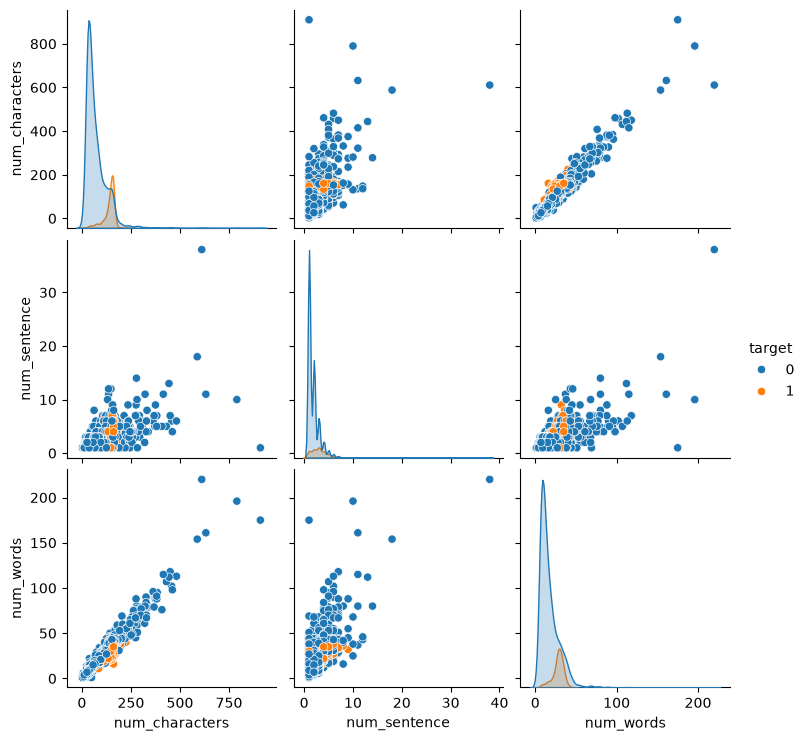

In [121]:
sns.pairplot(sms, hue='target')

In [122]:
sms.corr(numeric_only=True)

,target,num_characters,num_sentence,num_words
target,1.000000,0.384717,0.263939,0.262912
num_characters,0.384717,1.000000,0.624139,0.965760
num_sentence,0.263939,0.624139,1.000000,0.679971
num_words,0.262912,0.965760,0.679971,1.000000


<Axes: >

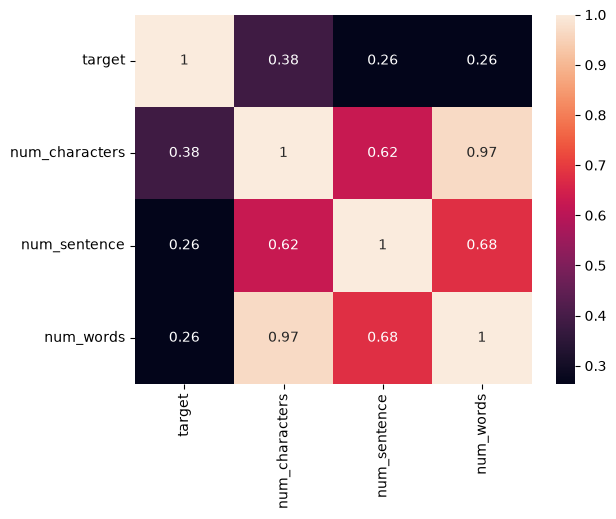

In [123]:
sns.heatmap(sms.corr(numeric_only=True), annot=True)

In [124]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk

def transform(text):
    
    # Lowercase
    text = text.lower()
    
    # Tokenization
    tokens = nltk.word_tokenize(text)
    
    # Remove non-alphanumeric tokens
    tokens = [word for word in tokens if word.isalnum()]
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    # Stemming
    ps = PorterStemmer()
    tokens = [ps.stem(word) for word in tokens]
    
    return " ".join(tokens)

In [125]:
sms['transformed_text'] = sms['text'].apply(transform)

In [126]:
sms.head()

,target,text,num_characters,num_sentence,num_words,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,2,24,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,2,8,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,2,37,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,1,13,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,1,15,nah think goe usf live around though


In [127]:
from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, min_font_size=12, background_color='white')

In [128]:
spam_wc = wc.generate(sms[sms['target'] == 1]['transformed_text'].str.cat(sep= " "))

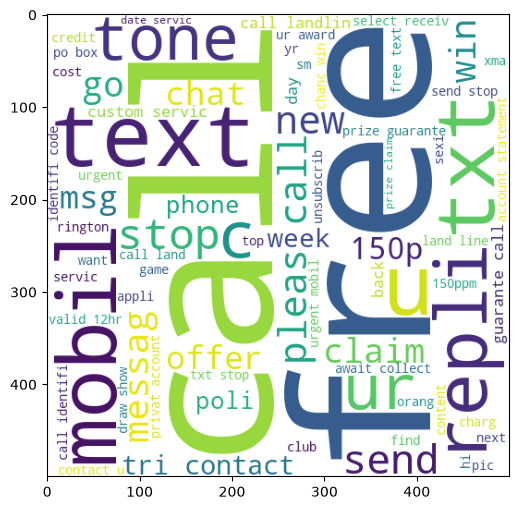

In [129]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [130]:
ham_wc = wc.generate(sms[sms['target'] == 0]['transformed_text'].str.cat(sep= " "))

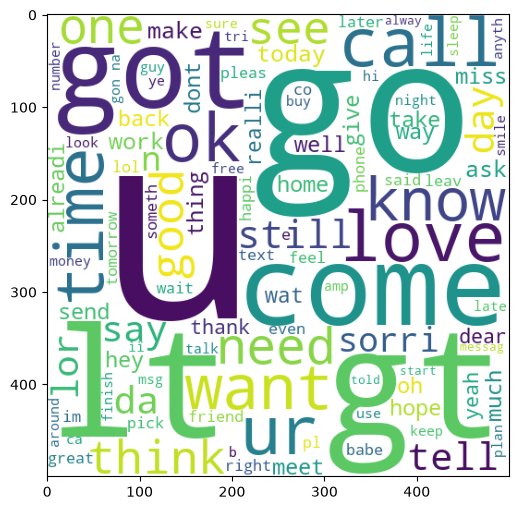

In [131]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [132]:
spam_corpus = []
for msg in sms[sms['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [133]:
len(spam_corpus)

9939

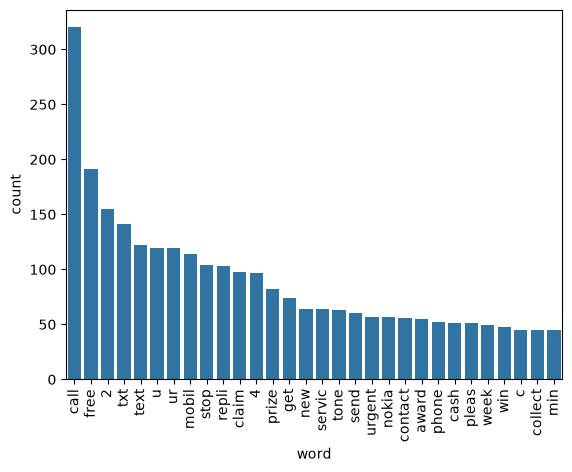

In [134]:
from collections import Counter

# Get top 30 words
common_words = Counter(spam_corpus).most_common(30)

# Create DataFrame
df = pd.DataFrame(common_words, columns=['word', 'count'])

# Plot
sns.barplot(x='word', y='count', data=df)
plt.xticks(rotation = 'vertical')
plt.show()

In [135]:
ham_corpus = []
for msg in sms[sms['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [136]:
len(ham_corpus)

35404

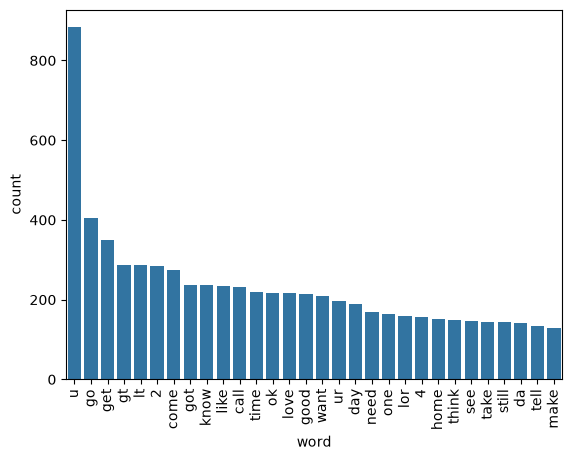

In [137]:
# Get top 30 words
common_words = Counter(ham_corpus).most_common(30)

# Create DataFrame
df = pd.DataFrame(common_words, columns=['word', 'count'])

# Plot
sns.barplot(x='word', y='count', data=df)
plt.xticks(rotation = 'vertical')
plt.show()

In [138]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

cv = CountVectorizer()
tfid = TfidfVectorizer(max_features= 3000)

In [139]:
X = tfid.fit_transform(sms['transformed_text']).toarray()

In [140]:
y = sms['target'].values

In [141]:
X.shape, y.shape

((5169, 3000), (5169,))

In [142]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, recall_score, f1_score

from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [143]:
models = {
    "SVC": SVC(kernel='sigmoid', gamma=1.0),

    "KNN": KNeighborsClassifier(),

    "Multinomial_NB": MultinomialNB(),

    "DecisionTree": DecisionTreeClassifier(max_depth=5),

    "LogisticRegression": LogisticRegression(
        solver='liblinear',
        penalty='l1'
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=50,
        random_state=2
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=50,
        random_state=2
    ),

    "Bagging": BaggingClassifier(
        n_estimators=50,
        random_state=2
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=50,
        random_state=2
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=50,
        random_state=2
    ),

    "XGBoost": XGBClassifier(
        n_estimators=50,
        random_state=2,
        eval_metric='logloss'
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=50,
        random_state=2,
        verbose=-1
    )
}

In [144]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [145]:
result = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    result.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(result)


In [146]:
results_df = results_df.sort_values("Precision", ascending=False, ignore_index='True')

print(results_df)

                 Model  Accuracy  Precision    Recall        F1
0                  KNN  0.914894   1.000000  0.393103  0.564356
1           ExtraTrees  0.979691   1.000000  0.855172  0.921933
2       Multinomial_NB  0.972921   0.991597  0.813793  0.893939
3         RandomForest  0.971954   0.991525  0.806897  0.889734
4             LightGBM  0.970019   0.967213  0.813793  0.883895
5     GradientBoosting  0.949710   0.951456  0.675862  0.790323
6                  SVC  0.975822   0.947761  0.875862  0.910394
7              XGBoost  0.968085   0.937500  0.827586  0.879121
8              Bagging  0.960348   0.876812  0.834483  0.855124
9   LogisticRegression  0.946809   0.862903  0.737931  0.795539
10        DecisionTree  0.933269   0.827586  0.662069  0.735632
11            AdaBoost  0.913926   0.791667  0.524138  0.630705


In [147]:
results_df1 = pd.melt(results_df, id_vars='Model')

In [148]:
results_df1.sort_values('value', ascending=False, ignore_index=True)

,Model,variable,value
0,KNN,Precision,1.000000
1,ExtraTrees,Precision,1.000000
2,Multinomial_NB,Precision,0.991597
3,RandomForest,Precision,0.991525
4,ExtraTrees,Accuracy,0.979691
5,SVC,Accuracy,0.975822
6,Multinomial_NB,Accuracy,0.972921
7,RandomForest,Accuracy,0.971954
8,LightGBM,Accuracy,0.970019
9,XGBoost,Accuracy,0.968085


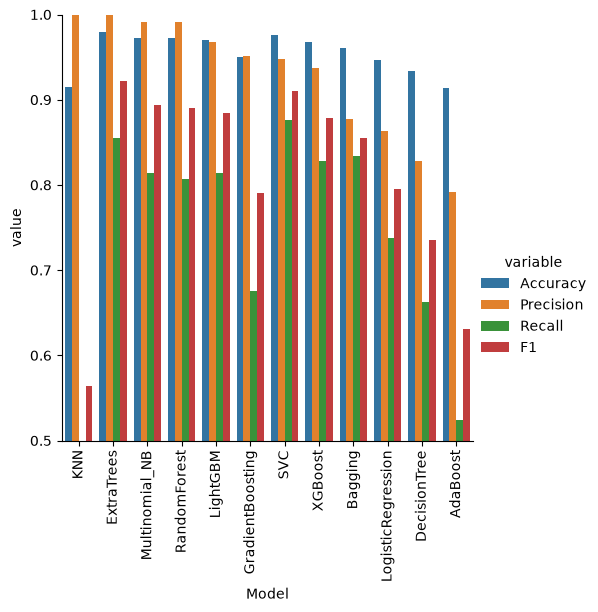

In [149]:
sns.catplot(x = 'Model', y ='value', hue='variable', data=results_df1, kind='bar', height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation = 'vertical')
plt.show()

In [150]:
# model = models["Multinomial_NB"]

# model.fit(X_train, y_train)

In [154]:
models["Multinomial_NB"].predict(X_test[:5])

array([0, 0, 0, 0, 0])

In [155]:
import joblib

joblib.dump(tfid, "../reports/models/vectors.pkl")
joblib.dump(models["Multinomial_NB"], "../reports/models/model.pkl")

['../reports/models/model.pkl']

In [156]:
vectorizer = joblib.load("../reports/models/vectors.pkl")
model = joblib.load("../reports/models/model.pkl")

print(type(vectorizer))
print(type(model))

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
<class 'sklearn.naive_bayes.MultinomialNB'>
